# Phase 2: Exploratory Data Analysis — xBD Disaster Damage Data

## 1. Objective

This notebook explores the labeled building data across candidate disaster types to make an evidence-based final decision on the training set composition, and to understand the underlying data (class balance, building sizes, image resolution) before any preprocessing or modeling begins.

**Starting point:** Phase 1 confirmed `hurricane-harvey` and `hurricane-michael` as a verified, well-aligned 2-disaster training set. This phase investigates whether a 3rd training disaster is genuinely justified by real class-distribution evidence, rather than assumption or small visual samples — following the discipline established in Phase 1's `socal-fire` re-evaluation.

## 2. What This Notebook Covers

1. **2.1** — Damage-class distribution across all 10 available disaster types, in raw counts and row-wise percentages
2. **2.2** — Building size / bounding-box distribution
3. **2.3** — Image resolution consistency check
4. **2.4** — Statistical Validation — Chi-Square Test of Independence
5. **2.5** — Building Size by Damage Class
6. **2.6** — Statistical Validation — KS-Test on Un-Classified vs. No-Damage Building Sizes
7. **2.7** — Building Density per Image
8. **2.8** — Phase 2 Summary

## 3. Held-Out Set

`mexico-earthquake` remains reserved exclusively for Phase 7's generalization test and is analyzed here only for its own class distribution (not as a training candidate), to keep it genuinely unseen by any training or tuning decision.

## 2.1 Damage-Class Distribution Across Disaster Types

**Task:** Count how many buildings fall into each damage class (`no-damage`, `minor-damage`, `major-damage`, `destroyed`, `un-classified`) for every disaster type in the training set — not just the current 2 training disasters, but all 10 available, so any decision about a 3rd training disaster is based on complete evidence rather than a small visual sample.

**Why this matters:** the current confirmed training set (`hurricane-harvey` + `hurricane-michael`) has only 2.5% `destroyed`-class representation combined — the most operationally important damage class for a disaster-response tool is also the most underrepresented in training data. This section quantifies that gap and checks whether any other disaster type can meaningfully close it, without duplicating existing damage patterns or compromising the integrity of the Phase 7 held-out test.

In [ ]:
import json
from collections import defaultdict
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LABELS_DIR = Path("../data/raw/train/labels")

DISASTERS = [
    "hurricane-harvey",
    "hurricane-michael",
    "hurricane-florence",
    "hurricane-matthew",
    "santa-rosa-wildfire",
    "socal-fire",
    "midwest-flooding",
    "palu-tsunami",
    "mexico-earthquake",
    "guatemala-volcano",
]

def get_disaster_damage_counts(disaster_name, labels_dir):
    """Counts damage class for a specific disaster."""
    pattern = f"*{disaster_name}*post_disaster.json" # specific pattern to follow
    
    # Finds all the matching pattern json files
    json_files = labels_dir.glob(pattern) # an iterator
    damage_counter = defaultdict(int)
    
    for file_path in json_files:
        with open(file_path, "r") as f:
            d = json.load(f)
            for building in d.get("features", {}).get("xy", []):
                subtype = building.get("properties", {}).get("subtype")
                if not subtype:
                    subtype = "un-classified"
                damage_counter[subtype] += 1
    
    return dict(damage_counter)              

summary_results = {}
for disaster in DISASTERS:
    counts = get_disaster_damage_counts(disaster, LABELS_DIR) 
    summary_results[disaster] = counts 

contingency_table = pd.DataFrame(summary_results).T.fillna(0)

# Add a total buildings column (sum across all damage-class columns, per row)
contingency_table['total_buildings'] = contingency_table.sum(axis=1)
  
# Create a percentage version — each class as % of that disaster's own total
damage_columns = ['no-damage', 'minor-damage', 'major-damage', 'destroyed', 'un-classified']
percentage_table = contingency_table[damage_columns].div(contingency_table['total_buildings'], axis=0) * 100
percentage_table = percentage_table.round(1)
percentage_table['total_buildings'] = contingency_table['total_buildings']

print(percentage_table)


                     no-damage  minor-damage  major-damage  destroyed  \
hurricane-harvey          49.6          11.6          35.8        1.7   
hurricane-michael         64.3          23.0           8.4        3.3   
hurricane-florence        72.7           2.0          19.3        0.8   
hurricane-matthew         18.0          47.0          14.0       15.4   
santa-rosa-wildfire       71.7           0.6           0.5       26.8   
socal-fire                82.5           0.8           0.5       12.7   
midwest-flooding          92.8           1.7           1.4        0.9   
palu-tsunami              81.1           0.0           1.8       15.8   
mexico-earthquake         99.4           0.3           0.1        0.0   
guatemala-volcano         74.6           1.1           1.1        2.9   

                     un-classified  total_buildings  
hurricane-harvey               1.3            23014  
hurricane-michael              1.0            22686  
hurricane-florence             5.1

### Observations

The full 10-disaster breakdown confirms the class imbalance concern: `hurricane-harvey` (1.7% destroyed) and `hurricane-michael` (3.3% destroyed) combined leave the `destroyed` class badly underrepresented relative to `no-damage`, `minor-damage`, and `major-damage`.

Four disasters showed meaningfully higher `destroyed` representation: `santa-rosa-wildfire` (26.8%), `palu-tsunami` (15.8%), `hurricane-matthew` (15.4%), and `socal-fire` (12.7%). Each was evaluated against three criteria before selection:

1. **Does it close the actual gap?** — ranked by `destroyed`% specifically, since that's the confirmed weak point in the current training set.
2. **Does it add genuine diversity, or duplicate an existing pattern?** — `hurricane-matthew` was excluded here: despite a strong `destroyed`% (15.4%), it shares the same wind/flood damage mechanism as the existing hurricane pair and would not teach the model a new damage pattern.
3. **Does it protect the Phase 7 held-out test's integrity?** — `palu-tsunami` was excluded here: it is a real-world combined earthquake+tsunami event, and adding it to training would blur the boundary between "seen" and "unseen" damage mechanisms relative to the `mexico-earthquake` held-out disaster.

`santa-rosa-wildfire` passed all three criteria — highest `destroyed`% by a wide margin, mechanically distinct from the existing hurricane pair (fire vs. wind/flood), and does not overlap with the earthquake held-out set. It also confirmed, with full counts rather than the earlier ~15-image sample, that its `un-classified` rate (0.4%) is low — the earlier concern about fire-damage labeling quality applied to `socal-fire` specifically (3.6% un-classified, still usable but noisier), not to fire disasters in general.

**Final training set decision:** `hurricane-harvey` + `hurricane-michael` + `santa-rosa-wildfire`.
**Held-out generalization disaster (Phase 7):** `mexico-earthquake` — confirmed as mechanically and statistically distinct from all training disasters (99.4% no-damage, near-zero destroyed), remaining a genuine, uncompromised test of generalization.

`guatemala-volcano` (856 buildings, 20.3% un-classified) is confirmed too small and label-ambiguous to be useful for any purpose in this project.

## 2.2 Building Footprint Size Distribution

**Task:** For the 3 confirmed training disasters (`hurricane-harvey`, `hurricane-michael`, `santa-rosa-wildfire`), compute each building's footprint area (in square pixels) from its pre-disaster polygon, and compare the size distributions across disasters.

**Why pre-disaster labels:** damage assessment happens on post-disaster imagery, but footprint size should reflect a building's intact state — post-disaster polygons for destroyed buildings can be fragmented or reduced, which would distort the "typical building size" this section is trying to establish.

**Why this matters:** Phase 4's segmentation model needs a realistic sense of building scale to inform crop size and input resolution decisions, and to judge whether small buildings are being detected accurately once training begins.

hurricane-harvey: 23014 buildings measured
hurricane-michael: 22686 buildings measured
santa-rosa-wildfire: 12950 buildings measured


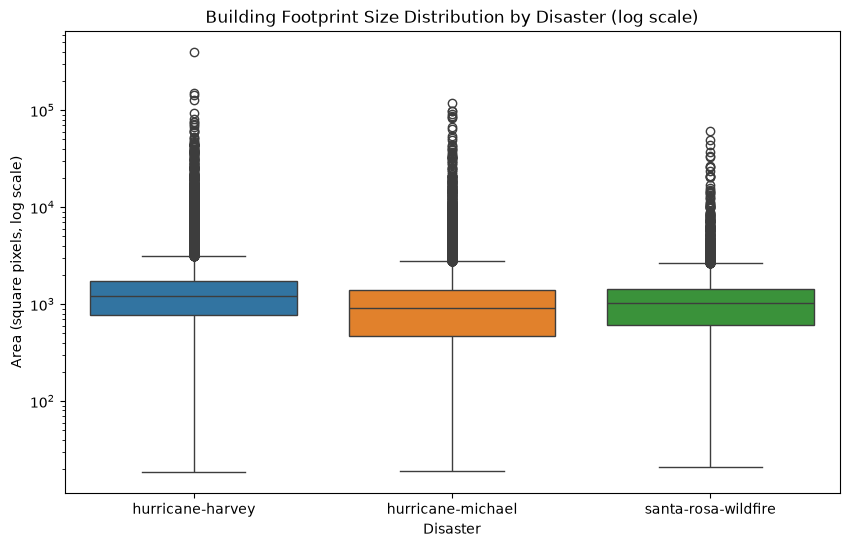

In [2]:
from shapely.wkt import loads as wkt_loads

def get_building_areas(disaster_name, labels_dir):
    """Returns the area of each building for a specific disaster."""
    pattern = f"*{disaster_name}*pre_disaster.json"
    json_files = labels_dir.glob(pattern)
    areas = []
    
    for file_path in json_files:
        with open(file_path, "r") as f:
            d = json.load(f)
            for building in d.get("features", {}).get("xy", []):
                wkt_str = building["wkt"]
                polygon = wkt_loads(wkt_str)
                areas.append(polygon.area)
    return areas

disasters = [
    "hurricane-harvey",
    "hurricane-michael",
    "santa-rosa-wildfire"
]

building_sizes = {}

for disaster in disasters:
    building_sizes[disaster] = get_building_areas(disaster, LABELS_DIR)
    print(f"{disaster}: {len(building_sizes[disaster])} buildings measured")


# Box plot needs one row per observation
plot_data = pd.DataFrame([
    {"disaster": disaster, "area" : area}
    for disaster, area_list in building_sizes.items()
    for area in area_list 
])   

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=plot_data,
    x="disaster",
    y="area",
    hue="disaster",
    palette="tab10",
    legend=False
)
plt.yscale("log")
plt.title("Building Footprint Size Distribution by Disaster (log scale)")
plt.xlabel("Disaster")
plt.ylabel("Area (square pixels, log scale)")
plt.show()

### Observations

Building footprint sizes are consistent across all three training disasters — medians cluster tightly between ~900-1,200 square pixels, with similar interquartile ranges (roughly 500-1,700 sq px). This is a good sign for the combined training set: `santa-rosa-wildfire` was selected purely for its damage-class diversity (Section 2.1), and this confirms it doesn't also introduce a conflicting building-scale distribution the segmentation model would need to separately account for.

All three disasters show the expected right-skewed distribution with a long tail of larger outlier buildings (warehouses, commercial structures) extending up to 10⁴-10⁵ square pixels — confirming the log-scale choice was necessary for a readable comparison. `hurricane-harvey` contains the single largest outlier (~4×10⁵ sq px), most likely one unusually large structure rather than a labeling error, given the rest of its distribution is otherwise consistent with the other two disasters.

**Implication for later phases:** since building scale is consistent across the combined training set, a single augmentation/crop-size strategy (Phase 3) should generalize reasonably well across all three disasters, without requiring per-disaster tuning.

## 2.3 Image Resolution Consistency Check

**Task:** Confirm that all pre-disaster and post-disaster images across the 3 final training disasters (`hurricane-harvey`, `hurricane-michael`, `santa-rosa-wildfire`) share a consistent resolution, checked explicitly and separately for pre and post images rather than inferred from a combined count.

**Why this matters:** Phase 3's preprocessing/augmentation pipeline processes pre and post image pairs together. Inconsistent resolutions — even between a single pair — would break or silently misalign that pipeline. This is a standard, low-cost sanity check worth confirming directly before any preprocessing work begins.

In [3]:
from PIL import Image

IMAGE_DIR = Path("../data/raw/train/images")

def get_image_dimensions_by_phase(disaster_name, phase, img_dir):
    """Count the dimensions of images belonging to a specific disaster."""
    dimensions = defaultdict(int)
    pattern = f"*{disaster_name}*{phase}_disaster*"
    
    # Loop through every image with following above pattern
    for image_path in img_dir.glob(pattern):
        if image_path.suffix.lower() in [".png", ".jpg", ".jpeg"]: # suffix gives extension
            with Image.open(image_path) as img:  # image object
                dimensions[img.size] += 1 # (1024, 1024) or (512, 512)
    return dict(dimensions)

for disaster in disasters:
    pre_dims = get_image_dimensions_by_phase(disaster, "pre", IMAGE_DIR)
    post_dims = get_image_dimensions_by_phase(disaster, "post", IMAGE_DIR)
    print(f"{disaster} — pre: {pre_dims} | post: {post_dims}")


hurricane-harvey — pre: {(1024, 1024): 319} | post: {(1024, 1024): 319}
hurricane-michael — pre: {(1024, 1024): 343} | post: {(1024, 1024): 343}
santa-rosa-wildfire — pre: {(1024, 1024): 226} | post: {(1024, 1024): 226}


### Observations

All pre-disaster and post-disaster images across the 3 training disasters share a single, consistent resolution: 1024×1024. This holds explicitly for both phases separately — `hurricane-harvey` (319 pre, 319 post), `hurricane-michael` (343 pre, 343 post), and `santa-rosa-wildfire` (226 pre, 226 post) — with zero deviation in any bucket.

This confirms no extra resizing or resolution-normalization step is needed before Phase 3's preprocessing pipeline — a single crop/augmentation configuration can be applied uniformly across the combined training set, consistent with the earlier finding (Section 2.2) that building footprint sizes are also comparable across all three disasters.

## 2.4 Statistical Validation — Chi-Square Test of Independence

**Task:** Formally test whether damage-class distribution significantly differs across the 3 training disasters (`hurricane-harvey`, `hurricane-michael`, `santa-rosa-wildfire`), rather than relying only on the qualitative percentage comparison from Section 2.1.

**Why this matters:** Section 2.1's percentages showed clear differences (e.g. `santa-rosa-wildfire`'s 26.8% destroyed vs. harvey/michael's combined 2.5%), but a percentage difference alone doesn't confirm the difference is statistically real rather than sampling noise. A chi-square test of independence formally tests whether disaster type and damage class are associated — reusing the same statistical technique applied to categorical feature validation in the fraud-risk engine project, now applied to this project's own data.

In [4]:
from scipy.stats import chi2_contingency

contingency_table = pd.DataFrame({
    disaster: summary_results[disaster]
    for disaster in disasters
}).T.fillna(0) # summary table

chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_val:.4e}")
print(f"Degrees of Freedom: {dof}")

if p_val < 0.05:
    print("Result: Disaster type is significantly associated to damage status.")
else:
    print("Result: Disaster type has NO significant association to damage status.")

Chi-Square Statistic: 19218.0388
p-value: 0.0000e+00
Degrees of Freedom: 8
Result: Disaster type is significantly associated to damage status.


### Observations

The chi-square test confirms, with statistical rigor, that the damage-class distribution differs significantly across the three disaster types (χ² = 19218.04, p < 0.0001 — reported as `0.0000e+00` due to floating-point precision limits at this sample size, not a literal zero). Degrees of freedom (8) match the expected calculation: (3 disaster types − 1) × (5 damage classes − 1).

This result should be read carefully: with a large combined sample (~50,000+ buildings), even small differences would register as statistically significant, so this test primarily confirms the differences observed in Section 2.1 are real and not due to random sampling variation — it does not, by itself, measure how large those differences are. The actual magnitude was already established in Section 2.1's percentage breakdown (e.g. `santa-rosa-wildfire`'s 26.8% destroyed rate vs. harvey/michael's ~2.5% combined).

**Combined conclusion (2.1 + 2.4):** the training-disaster selection is now backed by both a practical, magnitude-based comparison (2.1) and a formal statistical significance test (2.4) — a stronger, more defensible basis for the decision than either alone.

## 2.5 Building Size by Damage Class

**Task:** Compare building footprint size distributions across damage classes (`no-damage`, `minor-damage`, `major-damage`, `destroyed`, `un-classified`), combining all 3 training disasters, to check whether damage severity correlates with building size — a pattern not yet examined in Section 2.2, which compared sizes across disasters rather than across damage classes.

**Why this matters:** if damage severity correlates with building size, that's either a useful signal the classifier (Phase 5) could learn from, or a confound worth being aware of when interpreting model behavior later. This also investigates a specific open question from Section 2.1: why do certain disasters produce more `un-classified` labels than others?

major-damage: 10203 buildings
minor-damage: 7948 buildings
no-damage: 35296 buildings
un-classified: 574 buildings
destroyed: 4629 buildings


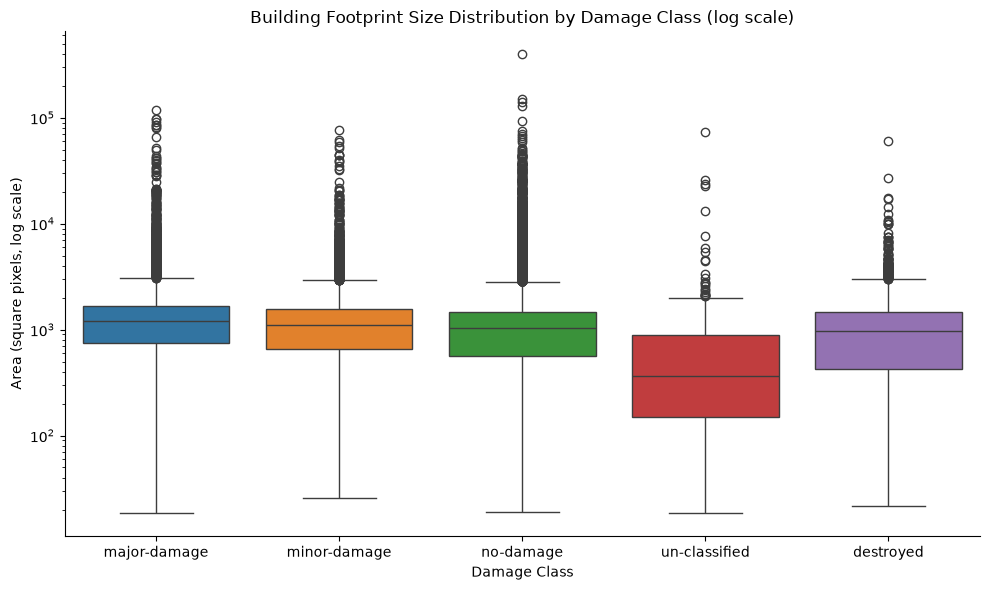

In [ ]:
def get_area_per_damage_class(disaster_name, labels_dir):
    """Returns the areas for each damage class."""
    pattern = f"*{disaster_name}*post_disaster.json" 
    json_files = labels_dir.glob(pattern)
    area_by_class = defaultdict(list)
    
    for file_path in json_files:
        with open(file_path, "r") as f:
            d = json.load(f)
            for building in d.get("features", {}).get("xy", []):
                wkt_str = building["wkt"]
                subtype = building.get("properties", {}).get("subtype") # damage_class
                if not subtype:
                    subtype = "un-classified"
                polygon = wkt_loads(wkt_str)
                area_by_class[subtype].append(polygon.area)
                
    return dict(area_by_class)

combined_area_by_class = defaultdict(list)                
for disaster in disasters:
    result = get_area_per_damage_class(disaster, LABELS_DIR)
    for damage_class, areas in result.items():
        combined_area_by_class[damage_class].extend(areas)

for damage_class, areas in combined_area_by_class.items():
    print(f"{damage_class}: {len(areas)} buildings")

# Box plot needs one row per observation
plot_data = pd.DataFrame([
    {"damage_class": damage_class, "area" : area}
    for damage_class, area_list in combined_area_by_class.items()
    for area in area_list 
])   

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=plot_data,
    x="damage_class",
    y="area",
    hue="damage_class",
    palette="tab10",
    legend=False
)
plt.xlabel("Damage Class")
plt.title("Building Footprint Size Distribution by Damage Class (log scale)")
plt.ylabel("Area (square pixels, log scale)")
plt.yscale("log")
sns.despine() # removes top and right borders
plt.tight_layout()
plt.show()

### Observations

`no-damage`, `minor-damage`, `major-damage`, and `destroyed` all show roughly similar medians (~900-1,200 sq px) and similar interquartile ranges — damage severity does not appear to correlate strongly with building size across these four classes. All four show the expected right-skewed distribution with numerous outliers, consistent with Section 2.2's findings, including one extreme outlier in `no-damage`, consistent with the single large outlier observed there.

`un-classified`, however, stands apart: its median (~350 sq px) and its entire interquartile range sit clearly below the other four classes — `un-classified` buildings tend to be smaller than damage-labeled buildings.

**This offers a plausible explanation for an earlier finding (Section 2.1):** fire disasters (`socal-fire`, and to a lesser extent `santa-rosa-wildfire`) showed disproportionately higher `un-classified` rates than other disaster types. Smaller, less clearly visible structures are plausibly harder for human annotators to confidently assess for damage — leading to more `un-classified` labels — which may explain why fire-damaged areas, potentially containing more small/ambiguous structures, produced more unclassified buildings than other disaster types. This connects two previously separate EDA findings into one coherent explanation, rather than treating them as unrelated observations.

## 2.6 Statistical Validation — KS-Test on Un-Classified vs. No-Damage Building Sizes

**Task:** Formally test whether `un-classified` buildings are statistically smaller than `no-damage` buildings, confirming the pattern observed visually in Section 2.5's boxplot with a Kolmogorov-Smirnov two-sample test.

**Why this matters:** Section 2.5's boxplot suggested `un-classified` buildings are smaller than damage-labeled buildings, which offered a plausible explanation for Section 2.1's finding that fire disasters produce disproportionately more `un-classified` labels. A KS-test formally confirms whether this apparent size difference is statistically real, and — unlike the chi-square test in Section 2.4 — its statistic value directly quantifies the *magnitude* of the difference between the two distributions, not just whether a difference exists.

In [6]:
from scipy.stats import ks_2samp

ks_stat, p_val = ks_2samp(combined_area_by_class["no-damage"], combined_area_by_class["un-classified"])

print(f"KS Statistic: {ks_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("Result: The size distributions are significantly different.")
else:
    print("Result: No significant difference in size distributions.")

KS Statistic: 0.3916
p-value: 1.4947e-78
Result: The size distributions are significantly different.


### Observations

The KS-test confirms `un-classified` buildings are significantly smaller than `no-damage` buildings (KS statistic = 0.3916, p = 1.49×10⁻⁷⁸). Unlike Section 2.4's chi-square statistic, the KS statistic directly represents the maximum separation between the two cumulative distributions on a 0-to-1 scale — a value of ~0.39 indicates a substantial, meaningful difference, not merely a statistically detectable one inflated by large sample size.

**Combined conclusion (2.5 + 2.6):** `un-classified` buildings are confirmed, both visually and statistically, to be meaningfully smaller than properly damage-labeled buildings. This supports a plausible mechanistic explanation for Section 2.1's finding that fire disasters (`socal-fire` in particular) show elevated `un-classified` rates: smaller, less clearly visible structures are likely harder for human annotators to confidently assess for damage, leading to more `un-classified` labels in disaster imagery containing more small or ambiguous structures. This connects three separate EDA findings (2.1's disaster-level un-classified rates, 2.5's size-by-damage-class pattern, 2.6's statistical confirmation) into one coherent, evidence-backed explanation.

## 2.7 Building Density per Image

**Task:** For each of the 3 training disasters, count how many buildings appear in each post-disaster image, and examine the distribution (min, max, mean, and shape) across images.

**Why this matters:** Phase 3's crop/patch strategy and Phase 4's segmentation model both need to handle images ranging from sparse (few buildings) to dense (many buildings) correctly. Knowing this distribution upfront sets realistic expectations for segmentation difficulty and informs preprocessing decisions, rather than discovering wide density variation as a surprise mid-training.

Min: 0, Max: 339, Mean: 72.1


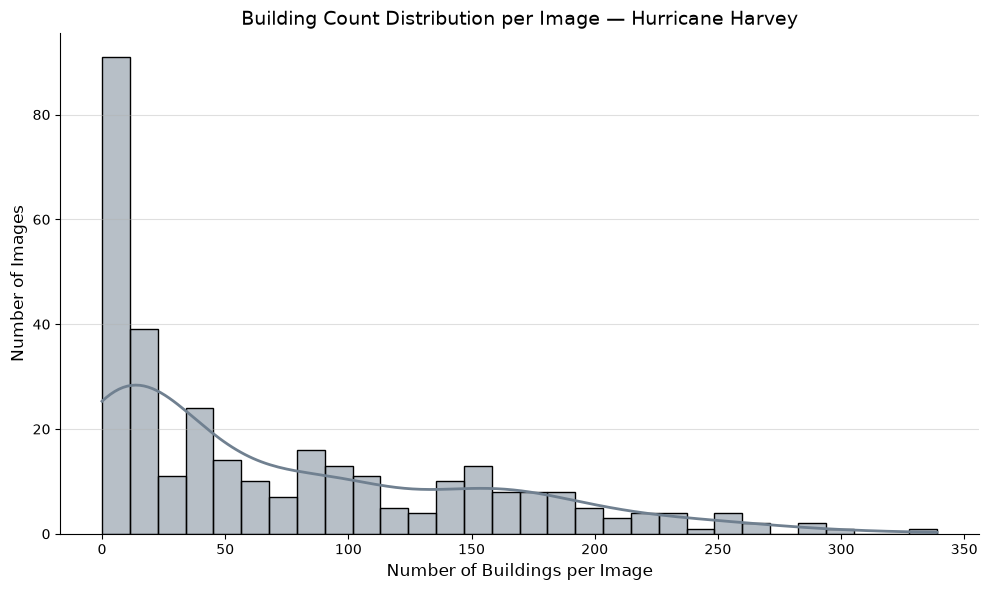

Min: 0, Max: 230, Mean: 66.1


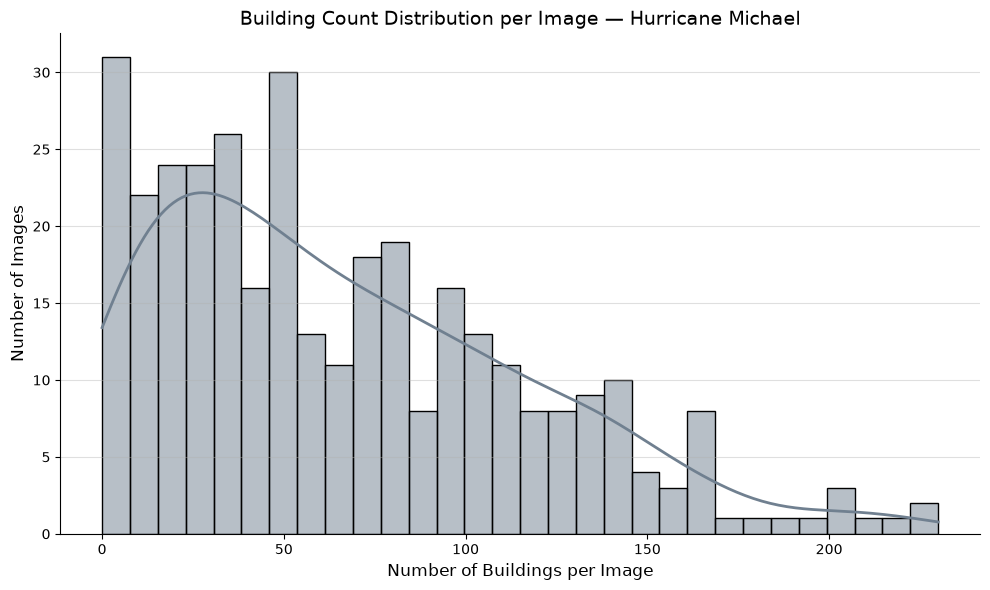

Min: 0, Max: 301, Mean: 57.3


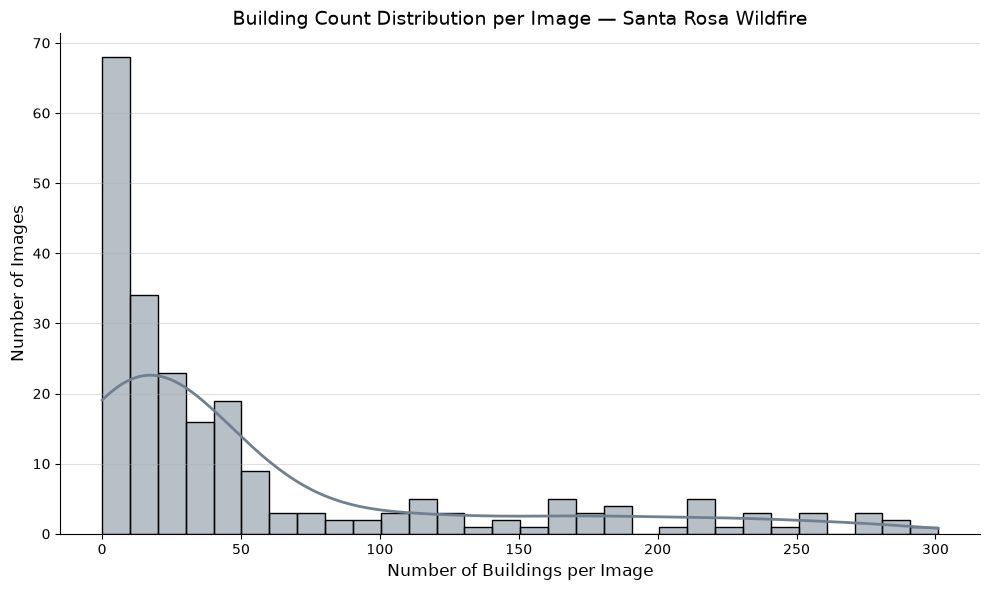

In [ ]:
def get_buildings_count_per_image(disaster_name, labels_dir):
    """Returns the number of buildings in each post-disaster image."""
    pattern = f"*{disaster_name}*post_disaster.json"
    json_files = labels_dir.glob(pattern)
    image_count = []
    
    for file in json_files:
        with open(file ,"r") as f:
            d = json.load(f)
            image_count.append(len(d.get("features", {}).get("xy", []))) # each image contains many buildings
    return image_count

for disaster in disasters:
    
    result = get_buildings_count_per_image(disaster, LABELS_DIR)
    print(f"Min: {min(result)}, Max: {max(result)}, Mean: {sum(result)/len(result):.1f}")
    
    plt.figure(figsize=(10, 6))
    sns.histplot(result,
                 kde=True,
                 color="slategray",
                 bins=30,
                 line_kws={"linewidth": 2}
                 )
    
    plt.xlabel("Number of Buildings per Image", fontsize=12)
    plt.ylabel("Number of Images",fontsize=12)
    plt.title(
    f"Building Count Distribution per Image — {disaster.replace('-', ' ').title()}",
    fontsize=14
    )
    plt.grid(axis="y", alpha=0.4)
    sns.despine() # removes top and right borders
    plt.tight_layout()
    plt.show()

### Observations

All three training disasters show a strongly right-skewed distribution: most images contain relatively few buildings (a large spike near 0-20 buildings per image), with a long tail extending to a small number of very dense images (up to 339 buildings for `hurricane-harvey`, 301 for `hurricane-michael`, 230 for `santa-rosa-wildfire`).

`hurricane-michael` stands out with a notably different shape than the other two — rather than one sharp spike near zero, it shows a broader spread across low-to-moderate building counts (a secondary peak around 40-50 buildings) before tapering off, and has the lowest mean (57.3) despite having a similarly high maximum to the others. This suggests `hurricane-michael`'s imagery covers a more consistent mix of moderately populated areas, whereas `hurricane-harvey` and `santa-rosa-wildfire` include a larger proportion of near-empty or lightly built images alongside their dense outliers.

**Implication for later phases:** all three disasters include some very dense images (200+ buildings) that will be significantly harder segmentation targets than the typical sparse image. Phase 3's crop strategy should account for this range rather than assuming a "typical" density, and Phase 4's per-image evaluation (Phase 6) should consider building density as a factor when interpreting cases of lower segmentation performance — a dense image failing partially is a different finding than a sparse image failing completely.

## 2.8 Phase 2 Summary

This phase moved the project's training-disaster selection from a plausible starting guess to an evidence-backed decision, and characterized the resulting dataset thoroughly enough to inform Phases 3-7.

**Key decisions made:**
- **Final training set:** `hurricane-harvey` + `hurricane-michael` + `santa-rosa-wildfire`, selected after full-count analysis across all 10 available disaster types (Section 2.1) closed a critical `destroyed`-class gap (2.5% → 7.9% combined) without duplicating existing damage mechanisms or compromising the held-out test.
- **Held-out generalization disaster confirmed:** `mexico-earthquake` (99.4% no-damage, mechanically distinct from all training disasters).
- **`socal-fire` re-evaluated and correctly excluded** — its full-count `un-classified` rate (3.6%) was much lower than an earlier small sample suggested, but `santa-rosa-wildfire` still offered a stronger benefit.

**Key characteristics established about the training data:**
- Building footprint sizes are consistent across all 3 disasters (Section 2.2) and across damage classes, except `un-classified` buildings, which are significantly smaller (Sections 2.5-2.6) — offering a plausible explanation for why fire disasters show elevated `un-classified` rates.
- Image resolution is uniformly 1024×1024 across all training data (Section 2.3), requiring no normalization before Phase 3.
- Damage-class distribution differs significantly across disasters, confirmed statistically (Section 2.4), not just observationally.
- Building density per image is highly variable and right-skewed across all 3 disasters, with `hurricane-michael` showing a distinct, more evenly-spread pattern (Section 2.7) — a factor to account for in Phase 3 preprocessing and Phase 6 evaluation.

**Statistical techniques applied:** chi-square test of independence (categorical distribution comparison) and KS-test (continuous distribution comparison) — both reused from the fraud-risk engine project, now validated in a second, different domain.

Phase 2 is complete. Proceeding to Phase 3: Preprocessing & Augmentation Pipeline.